# D2C Customer Churn Intelligence
## Objective
The objective of this analysis is to understand behavior, identity data quality issues, explore churn-related patterns, and generate business hypotheses before building predictive models.
Snapshot Date: 2025-09-30
Target: Predict whether customer will churn within the next 60 days.

In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

CHART_DIR = Path("../outputs/charts")
TABLE_DIR = Path("../outputs/tables")

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# Load Datasets

In [34]:

customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
tickets = pd.read_csv("../data/support_tickets.csv")
web = pd.read_csv("../data/web_events_snapshot.csv")
campaigns = pd.read_csv("../data/intervention_history.csv")
churn = pd.read_csv("../data/churn_labels.csv")


# Dataset Overview

In [35]:
# Dataset Overview

datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaigns": campaigns,
    "churn": churn
}

overview = pd.DataFrame(
    [
        [name, df.shape[0], df.shape[1]]
        for name, df in datasets.items()
    ],
    columns=["Dataset", "Rows", "Columns"]
)

# Display nicely in notebook
display(overview)

# Save CSV
overview.to_csv(
    TABLE_DIR / "dataset_overview.csv",
    index=False
)

# Save Markdown table
with open(
    TABLE_DIR / "dataset_overview.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(overview.to_markdown(index=False))

# Save table as image
fig, ax = plt.subplots(figsize=(8, 3))

ax.axis("off")

table = ax.table(
    cellText=overview.values,
    colLabels=overview.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title(
    "Dataset Overview",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.savefig(
    CHART_DIR / "dataset_overview_table.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

print("✓ Dataset overview saved successfully")

,Dataset,Rows,Columns
0,customers,2400,9
1,orders,10009,10
2,tickets,1921,8
3,web,2400,10
4,campaigns,2400,5
5,churn,2400,4


✓ Dataset overview saved successfully


## Dataset Overview - Key Observations

- The analysis uses six datasets covering customer profiles, transactions, support interactions, web activity, campaign history, and churn labels.
- The customer dataset acts as the master table containing 2,400 unique customers.
- The orders dataset is the largest source with 10,009 transaction records.
- Support ticket data contains 1,921 records, indicating that not every customer interacts with customer support.
- Web activity, campaign history, and churn labels contain one record per customer and can be joined directly using `customer_id`.
- All datasets share a common key (`customer_id`), enabling customer-level analysis across multiple behavioral dimensions.

# Schema Inspection

# Schema Inspection

The purpose of this section is to understand the structure, data types, cardinality, and completeness of each dataset before performing data-quality checks and exploratory analysis.

Key objectives:

- Verify column data types
- Identify potential primary keys
- Identify nullable columns
- Understand dataset granularity (customer-level vs transaction-level)
- Detect potential issues that may affect joins or downstream analysis

In [36]:
schema_summary = []

for dataset_name, df in datasets.items():

    for column in df.columns:

        schema_summary.append([
            dataset_name,
            column,
            str(df[column].dtype),
            df[column].isnull().sum(),
            df[column].nunique()
        ])

schema_df = pd.DataFrame(
    schema_summary,
    columns=[
        "Dataset",
        "Column",
        "Data Type",
        "Missing Values",
        "Unique Values"
    ]
)

display(schema_df.head(20))

schema_df.to_csv(
    TABLE_DIR / "schema_summary.csv",
    index=False
)

print("✓ Schema summary saved successfully")

,Dataset,Column,Data Type,Missing Values,Unique Values
0,customers,customer_id,str,0,2400
1,customers,signup_date,str,0,609
2,customers,city_tier,str,0,3
3,customers,age_group,str,0,4
4,customers,acquisition_channel,str,0,6
5,customers,loyalty_tier,str,1386,3
6,customers,preferred_category,str,0,6
7,customers,skin_type,str,401,5
8,customers,marketing_consent,str,0,2
9,orders,order_id,str,0,10009


✓ Schema summary saved successfully


In [37]:
schema_preview = schema_df.head(15)

fig, ax = plt.subplots(figsize=(12, 5))

ax.axis("off")

table = ax.table(
    cellText=schema_preview.values,
    colLabels=schema_preview.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.4)

plt.title(
    "Schema Summary Preview",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    CHART_DIR / "schema_summary_preview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Data Quality Audit

Before performing exploratory analysis, it is important to assess the quality of the datasets.

This section focuses on:

- Missing values
- Duplicate-like records
- Invalid values
- Outliers
- Join consistency
- Leakage risks

Poor data quality can lead to misleading business conclusions and unreliable predictive models.

In [38]:
# Missing Values Analysis

missing_summary = []

for dataset_name, df in datasets.items():

    total_rows = len(df)

    for column in df.columns:

        missing_count = df[column].isnull().sum()

        missing_percentage = round(
            (missing_count / total_rows) * 100,
            2
        )

        missing_summary.append([
            dataset_name,
            column,
            missing_count,
            missing_percentage
        ])

# Create dataframe
missing_df = pd.DataFrame(
    missing_summary,
    columns=[
        "Dataset",
        "Column",
        "Missing Count",
        "Missing Percentage"
    ]
)

# Keep only columns that actually contain missing values
missing_only = (
    missing_df[
        missing_df["Missing Count"] > 0
    ]
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display in notebook
display(missing_only)

# Save CSV
missing_only.to_csv(
    TABLE_DIR / "missing_values_summary.csv",
    index=False
)

print("✓ Missing values summary saved")

,Dataset,Column,Missing Count,Missing Percentage
0,customers,loyalty_tier,1386,57.75
1,customers,skin_type,401,16.71
2,orders,rating,80,0.80


✓ Missing values summary saved


## Missing Values Analysis

Missing values may represent either:

1. Data collection issues
2. Legitimate business states

Understanding the reason for missingness is important before deciding whether to remove, impute, or retain records.

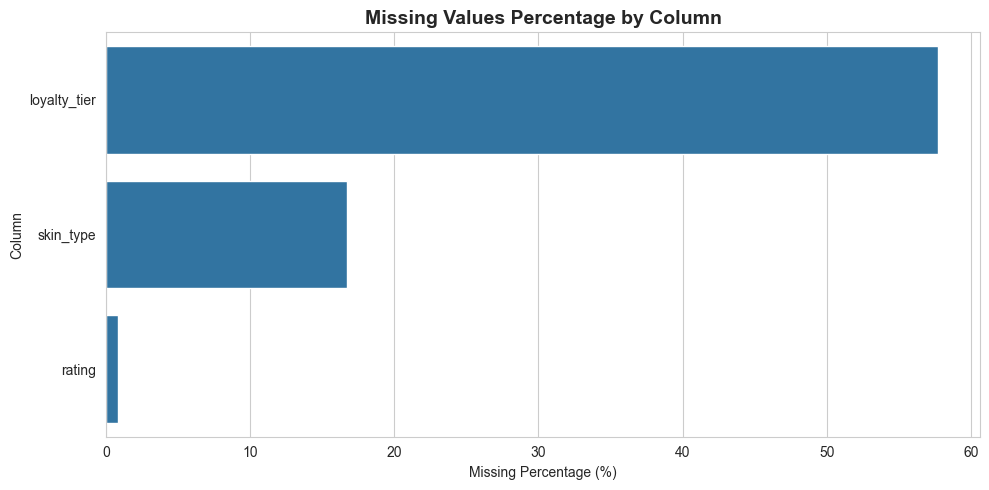

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_only,
    x="Missing Percentage",
    y="Column"
)

plt.title(
    "Missing Values Percentage by Column",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "missing_values_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Missing Value Findings

The missing-value audit identified three columns containing incomplete information.

### Key Findings

1. **Loyalty Tier (57.75% Missing)**

   - This is the most significant source of missingness.
   - Based on the data dictionary, null values indicate customers who are not enrolled in the loyalty program rather than a system error.
   - Missingness itself may therefore carry business meaning and should be retained as a separate category during future modeling.

2. **Skin Type (16.71% Missing)**

   - Missing values likely represent customers who chose not to provide this information during registration.
   - Since skin type is a self-reported profile attribute, missing values do not necessarily indicate poor data quality.

3. **Order Rating (0.80% Missing)**

   - A small number of customers did not leave ratings after purchases.
   - The impact on analysis is minimal, but missing ratings should be handled before calculating average satisfaction metrics.

### Recommendation

- Do not drop records because of missing values.
- Treat missing loyalty-tier values as "Not Enrolled".
- Treat missing skin-type values as "Unknown".
- Handle missing ratings separately when computing customer satisfaction features.

## Duplicate-Like Record Analysis

Duplicate records are a common data quality issue in transactional systems and can lead to inflated revenue, order counts, and customer activity metrics.

The data dictionary explicitly mentions the existence of duplicate-like order identifiers ending with the suffix `_DUP`.

The objective of this analysis is to:

- Identify duplicate-like transactions.
- Assess their frequency.
- Determine whether they should be removed before downstream analysis.
- Evaluate their potential impact on customer-level metrics.

In [40]:
# Duplicate-like Orders Audit

duplicate_like_orders = orders[
    orders["order_id"].str.contains(
        "_DUP",
        na=False
    )
].copy()

duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Duplicate-like Orders",
        "Duplicate-like Percentage"
    ],
    "Value": [
        len(orders),
        len(duplicate_like_orders),
        round(
            (len(duplicate_like_orders) / len(orders)) * 100,
            2
        )
    ]
})

display(duplicate_summary)

duplicate_summary.to_csv(
    TABLE_DIR /
    "duplicate_summary.csv",
    index=False
)

duplicate_like_orders.to_csv(
    TABLE_DIR /
    "duplicate_like_orders.csv",
    index=False
)

print("✓ Duplicate analysis saved")

,Metric,Value
0,Total Orders,10009.00
1,Duplicate-like Orders,12.00
2,Duplicate-like Percentage,0.12


✓ Duplicate analysis saved


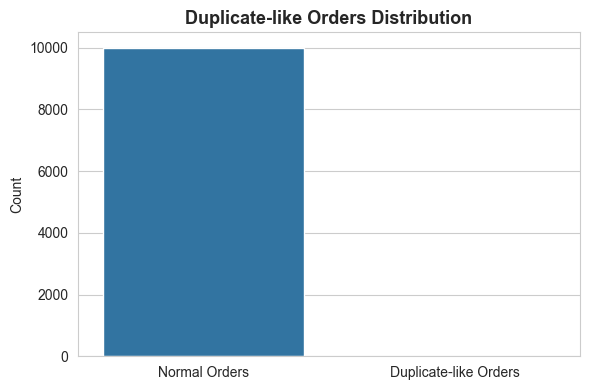

In [41]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=["Normal Orders", "Duplicate-like Orders"],
    y=[
        len(orders) - len(duplicate_like_orders),
        len(duplicate_like_orders)
    ]
)

plt.title(
    "Duplicate-like Orders Distribution",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "duplicate_like_orders_distribution.png",
    dpi=300
)

plt.show()

### Duplicate-Like Record Findings

A total of 12 duplicate-like order records were identified out of 10,009 transactions, representing approximately 0.12% of all orders.

Key observations:

- The number of duplicate-like records is very small relative to the overall dataset size.
- Duplicate-like records are distributed across multiple customers and categories.
- Some duplicate-like orders occur before the snapshot date, while others occur after the snapshot date.
- These records appear to be intentionally included as part of the data-quality exercise.

Recommendation:

- Flag duplicate-like records during feature engineering.
- Investigate whether they represent true duplicate transactions or replicated entries before removing them.
- For Part 1, retain the records and document their existence.

## Invalid Values & Data Consistency Checks

In addition to missing values and duplicate-like records, datasets may contain values that violate expected business rules.

Examples include:

- Negative quantities
- Discounts greater than 100%
- Invalid ratings
- Negative delivery times
- Invalid sentiment scores

These checks help ensure that downstream analysis is based on realistic and trustworthy data.

In [42]:
invalid_summary = []

# Quantity Check
invalid_summary.append([
    "Quantity < 1",
    (orders["quantity"] < 1).sum()
])

# Discount Check
invalid_summary.append([
    "Discount > 100%",
    (orders["discount_pct"] > 1).sum()
])

invalid_summary.append([
    "Discount < 0%",
    (orders["discount_pct"] < 0).sum()
])

# Delivery Days
invalid_summary.append([
    "Negative Delivery Days",
    (orders["delivery_days"] < 0).sum()
])

# Rating Check
invalid_summary.append([
    "Rating Outside 1-5",
    (
        (orders["rating"] < 1) |
        (orders["rating"] > 5)
    ).sum()
])

# Sentiment Check
invalid_summary.append([
    "Sentiment < -1",
    (tickets["sentiment_score"] < -1).sum()
])

invalid_summary.append([
    "Sentiment > 1",
    (tickets["sentiment_score"] > 1).sum()
])

invalid_df = pd.DataFrame(
    invalid_summary,
    columns=[
        "Validation Rule",
        "Invalid Records"
    ]
)

display(invalid_df)

invalid_df.to_csv(
    TABLE_DIR /
    "invalid_values_summary.csv",
    index=False
)

print("✓ Invalid values audit saved")

,Validation Rule,Invalid Records
0,Quantity < 1,0
1,Discount > 100%,0
2,Discount < 0%,0
3,Negative Delivery Days,0
4,Rating Outside 1-5,0
5,Sentiment < -1,0
6,Sentiment > 1,0


✓ Invalid values audit saved


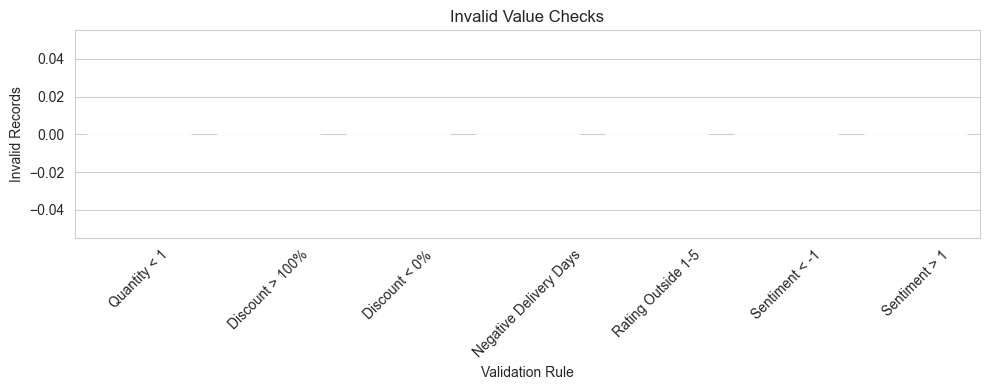

In [43]:
plt.figure(figsize=(10,4))

sns.barplot(
    data=invalid_df,
    x="Validation Rule",
    y="Invalid Records"
)

plt.xticks(rotation=45)

plt.title(
    "Invalid Value Checks"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "invalid_values_audit.png",
    dpi=300
)

plt.show()

### Invalid Values Audit Findings

A series of business-rule validation checks were performed across the transaction and support datasets.

The audit evaluated:

- Order quantity
- Discount percentages
- Delivery duration
- Customer ratings
- Ticket sentiment scores

#### Results

No invalid records were detected.

Key findings:

- All order quantities were greater than or equal to one.
- No discounts exceeded 100% or fell below 0%.
- No negative delivery durations were identified.
- All customer ratings were within the expected range of 1 to 5.
- All sentiment scores fell within the valid interval of -1 to +1.

#### Business Impact

The absence of invalid values suggests that core transactional and support-system validation controls are functioning correctly.

This increases confidence in the reliability of downstream customer behavior analysis and future predictive modeling activities.

In [51]:
## Outlier Analysis

Outliers can significantly influence customer-level metrics such as average order value, total spend, and customer lifetime value.

The objective of this analysis is to identify unusually large transactions and assess their potential impact on future analysis and modeling activities.

The `gross_amount` field is of particular interest because the data dictionary indicates the presence of intentionally injected high-value transactions.

SyntaxError: invalid syntax (1941762089.py, line 3)

In [ ]:
orders["gross_amount"].describe()

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title(
    "Gross Amount Outlier Detection",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "gross_amount_boxplot.png",
    dpi=300
)

plt.show()

In [ ]:
Q1 = orders["gross_amount"].quantile(0.25)
Q3 = orders["gross_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders[
    (orders["gross_amount"] < lower_bound) |
    (orders["gross_amount"] > upper_bound)
]

print(f"Outlier Orders: {len(outliers)}")

outliers[
    [
        "order_id",
        "customer_id",
        "gross_amount"
    ]
].head()

### Outlier Analysis Findings

The gross transaction amount (`gross_amount`) was analyzed using the Interquartile Range (IQR) method.

#### Key Statistics

| Metric | Value |
|----------|----------:|
| Mean Order Value | ₹743.90 |
| Median Order Value | ₹597.06 |
| Maximum Order Value | ₹24,789.38 |
| Outlier Orders | 536 |
| Total Orders | 10,009 |
| Outlier Percentage | 5.36% |

#### Observations

- The maximum order value is substantially larger than the median transaction value.
- The distribution is positively skewed, indicating the presence of a small number of unusually large purchases.
- Approximately 5.36% of orders were flagged as outliers using the IQR method.
- These transactions may represent bulk purchases, premium product bundles, or exceptional customer spending behavior.

#### Recommendation

- Outliers should not be automatically removed because they may represent genuine high-value customers.
- For future modeling, robust scaling or winsorization may be considered if extreme values significantly influence model performance.
- Customer-level spending metrics should be reviewed carefully to ensure that a small number of extreme transactions do not dominate overall trends.

In [49]:
outlier_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Outlier Orders",
        "Outlier Percentage",
        "Mean Gross Amount",
        "Median Gross Amount",
        "Maximum Gross Amount"
    ],
    "Value": [
        len(orders),
        len(outliers),
        round(
            len(outliers)/len(orders)*100,
            2
        ),
        round(
            orders["gross_amount"].mean(),
            2
        ),
        round(
            orders["gross_amount"].median(),
            2
        ),
        round(
            orders["gross_amount"].max(),
            2
        )
    ]
})

display(outlier_summary)

outlier_summary.to_csv(
    TABLE_DIR /
    "outlier_summary.csv",
    index=False
)

print("✓ Outlier summary saved")

,Metric,Value
0,Total Orders,10009.00
1,Outlier Orders,536.00
2,Outlier Percentage,5.36
3,Mean Gross Amount,743.90
4,Median Gross Amount,597.06
5,Maximum Gross Amount,24789.38


✓ Outlier summary saved


In [50]:
fig, ax = plt.subplots(figsize=(8,3))

ax.axis("off")

table = ax.table(
    cellText=outlier_summary.values,
    colLabels=outlier_summary.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.5)

plt.title(
    "Outlier Summary",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    CHART_DIR /
    "outlier_summary_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Data Consistency & Leakage Analysis

In [46]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

snapshot_date = pd.Timestamp(
    "2025-09-30"
)

post_snapshot_orders = orders[
    orders["order_date"] >
    snapshot_date
]

print(
    f"Post-Snapshot Orders: {len(post_snapshot_orders)}"
)

post_snapshot_orders.head()

Post-Snapshot Orders: 1872


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
7,ORD008129,CUST00002,2025-10-24,Skin Care,1,562.21,0.16,1,0,5.0
8,ORD008130,CUST00002,2025-10-26,Skin Care,1,569.89,0.18,4,0,4.0
15,ORD008132,CUST00005,2025-10-29,Hair Care,1,379.14,0.34,4,0,2.0
16,ORD008131,CUST00005,2025-11-19,Baby Care,3,980.38,0.22,4,0,4.0
22,ORD008133,CUST00006,2025-10-06,Baby Care,1,217.30,0.38,4,0,4.0


## Date Consistency & Leakage Analysis

The project documentation defines **2025-09-30** as the customer snapshot date.

Any transaction occurring after this date would not have been known at prediction time and therefore must not be used when building churn prediction features.

Using future transactions would introduce **data leakage**, causing models to learn information that would not be available in a real-world deployment scenario.

This section evaluates the presence and magnitude of post-snapshot transactions.

# Leakage Summary Table

In [52]:
leakage_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Post-Snapshot Orders",
        "Post-Snapshot Percentage"
    ],
    "Value": [
        len(orders),
        len(post_snapshot_orders),
        round(
            len(post_snapshot_orders) /
            len(orders) * 100,
            2
        )
    ]
})

display(leakage_summary)

leakage_summary.to_csv(
    TABLE_DIR /
    "leakage_summary.csv",
    index=False
)

print("✓ Leakage summary saved")

,Metric,Value
0,Total Orders,10009.0
1,Post-Snapshot Orders,1872.0
2,Post-Snapshot Percentage,18.7


✓ Leakage summary saved


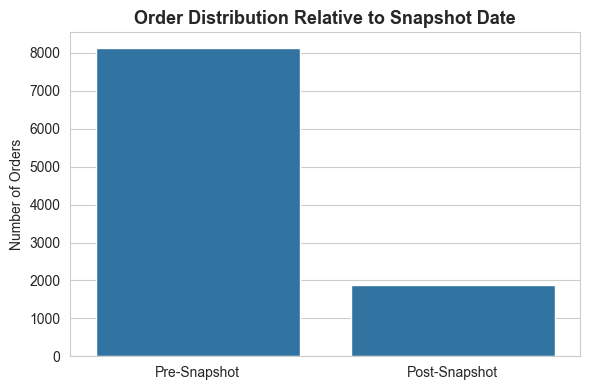

In [53]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=[
        "Pre-Snapshot",
        "Post-Snapshot"
    ],
    y=[
        len(orders) -
        len(post_snapshot_orders),

        len(post_snapshot_orders)
    ]
)

plt.title(
    "Order Distribution Relative to Snapshot Date",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "post_snapshot_orders.png",
    dpi=300
)

plt.show()

# Join Validation

In [ ]:
customer_ids = set(customers["customer_id"])

join_validation = pd.DataFrame({
    "Dataset": [
        "orders",
        "tickets",
        "web",
        "campaigns",
        "churn"
    ],
    "Records": [
        len(orders),
        len(tickets),
        len(web),
        len(campaigns),
        len(churn)
    ],
    "Orphan Records": [
        (~orders["customer_id"].isin(customer_ids)).sum(),
        (~tickets["customer_id"].isin(customer_ids)).sum(),
        (~web["customer_id"].isin(customer_ids)).sum(),
        (~campaigns["customer_id"].isin(customer_ids)).sum(),
        (~churn["customer_id"].isin(customer_ids)).sum()
    ]
})

display(join_validation)

# Join Validation

Customer-level analytics require reliable joins across all datasets.

To validate data integrity, each dataset was checked for customer identifiers that do not exist in the master customer table.

Such records are commonly referred to as orphan records and can lead to missing features, inaccurate aggregations, and incorrect customer profiles.

In [55]:
join_validation.to_csv(
    TABLE_DIR /
    "join_validation_summary.csv",
    index=False
)

print("✓ Join validation summary saved")

✓ Join validation summary saved


In [56]:
fig, ax = plt.subplots(figsize=(8,3))

ax.axis("off")

table = ax.table(
    cellText=join_validation.values,
    colLabels=join_validation.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.5)

plt.title(
    "Join Validation Summary",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    CHART_DIR /
    "join_validation_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

### Join Validation Findings

All datasets were successfully validated against the master customer table.

#### Results

| Dataset | Orphan Records |
|----------|----------:|
| Orders | 0 |
| Support Tickets | 0 |
| Web Activity | 0 |
| Campaign History | 0 |
| Churn Labels | 0 |

#### Key Observations

- No orphan customer identifiers were detected.
- Every transaction, support interaction, campaign record, web activity record, and churn label can be linked to a valid customer profile.
- This indicates strong referential integrity across the entire data ecosystem.

#### Business Impact

Reliable joins are critical for customer-level analytics and churn modeling.

The absence of orphan records ensures that customer features can be constructed consistently across all available data sources.

# Exploratory Data Analysis (EDA)

## Customer Demographics & Profile Analysis

This section explores the composition of the customer base and identifies demographic patterns that may influence customer behavior and churn.

In [59]:
customers["age_group"].value_counts()

age_group
25-34    1045
18-24     560
35-44     534
45+       261
Name: count, dtype: int64

## Age Group Distribution

Understanding the age composition of the customer base helps identify the dominant customer segments and provides context for future churn analysis.

Age groups may exhibit different purchasing patterns, engagement behaviors, and retention characteristics.

In [60]:
age_distribution = (
    customers["age_group"]
    .value_counts()
    .reset_index()
)

age_distribution.columns = [
    "Age Group",
    "Customer Count"
]

display(age_distribution)

age_distribution.to_csv(
    TABLE_DIR /
    "age_group_distribution.csv",
    index=False
)

print("✓ Age group table saved")

,Age Group,Customer Count
0,25-34,1045
1,18-24,560
2,35-44,534
3,45+,261


✓ Age group table saved


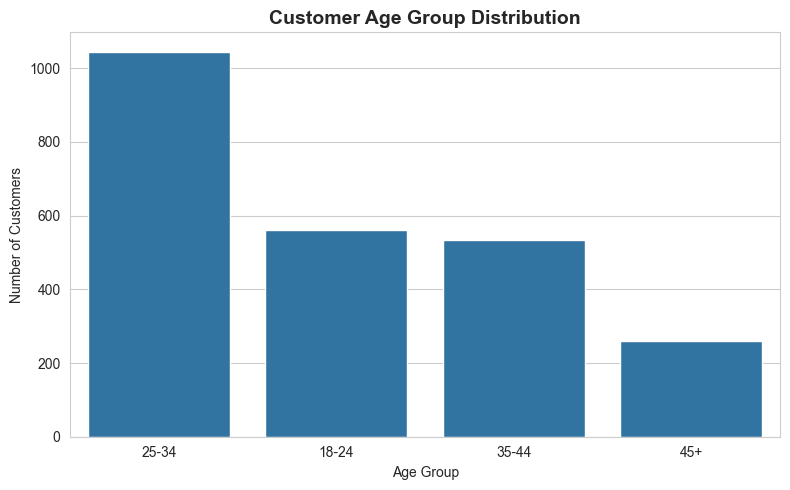

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="age_group",
    order=customers["age_group"]
        .value_counts()
        .index
)

plt.title(
    "Customer Age Group Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "customer_age_group_distribution.png",
    dpi=300
)

plt.show()

### Age Group Findings

The customer base is concentrated in younger and middle-aged segments.

#### Key Statistics

| Age Group | Customers |
|-----------|-----------:|
| 25–34 | 1,045 |
| 18–24 | 560 |
| 35–44 | 534 |
| 45+ | 261 |

#### Observations

- Customers aged **25–34** represent the largest segment, accounting for approximately 43.5% of the customer base.
- The **18–24** and **35–44** groups contribute similar volumes of customers.
- Customers aged **45+** represent the smallest segment.

#### Business Interpretation

The customer base is heavily concentrated among younger consumers, suggesting that marketing, product positioning, and customer engagement strategies are primarily attracting early-career and mid-career demographics.

Future churn analysis should investigate whether retention behavior differs across age groups.

In [62]:
customers["city_tier"].value_counts()

city_tier
Tier 1    1005
Tier 2     870
Tier 3     525
Name: count, dtype: int64